In [17]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import joblib


rfm = pd.read_csv("../data/processed/rfm_data.csv")
rfm.head()

,Customer ID,Recency,Frequency,Monetary,Cluster
0,12346.0,524,10,327.86,1
1,12347.0,35,7,3598.29,0
2,12348.0,244,4,353.16,0
3,12349.0,14,3,2787.09,0
4,12350.0,305,1,294.40,1


In [2]:
rfm["Recency"].describe()

count    5638.000000
mean      200.428166
std       206.518592
min         1.000000
25%        26.000000
50%       101.000000
75%       375.000000
max       734.000000
Name: Recency, dtype: float64

<Axes: xlabel='Recency', ylabel='Count'>

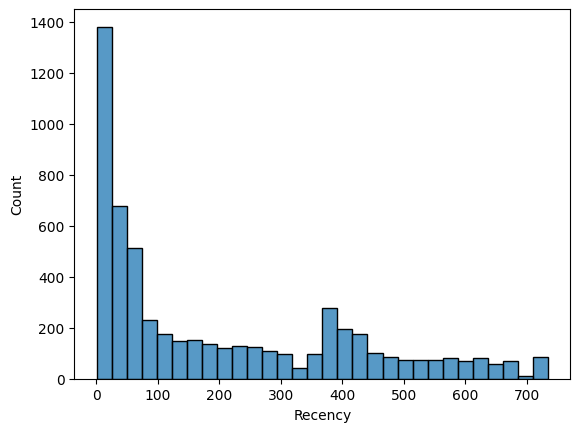

In [3]:
sns.histplot(rfm["Recency"], bins=30)

In [4]:
#Creating churn label, top 25% most inactive = churn
threshold = rfm["Recency"].quantile(0.75)
rfm["Churn"] = rfm["Recency"].apply(lambda x: 1 if x > threshold else 0)
rfm.head()

,Customer ID,Recency,Frequency,Monetary,Cluster,Churn
0,12346.0,524,10,327.86,1,1
1,12347.0,35,7,3598.29,0,0
2,12348.0,244,4,353.16,0,0
3,12349.0,14,3,2787.09,0,0
4,12350.0,305,1,294.40,1,0


In [5]:
rfm["Churn"].value_counts()

Churn
0    4236
1    1402
Name: count, dtype: int64

In [6]:
rfm["AvgOrderValue"] = rfm["Monetary"] / rfm["Frequency"]
rfm["AvgOrderValue"].fillna(0, inplace=True)

C:\Users\ARANYAK\AppData\Local\Temp\ipykernel_16684\3479709953.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  rfm["AvgOrderValue"].fillna(0, inplace=True)


In [7]:
X = rfm.drop("Churn", axis=1)
y = rfm["Churn"]

In [10]:
# Train / test split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [11]:
#scaling 
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [12]:
y.value_counts(normalize=True)

Churn
0    0.75133
1    0.24867
Name: proportion, dtype: float64

In [13]:
#Model Train (Logistic Regression)
model = LogisticRegression()
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [14]:
# Making predictions
y_pred = model.predict(X_test)

In [15]:
#Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Accuracy: 0.9822695035460993

Confusion Matrix:
[[830  18]
 [  2 278]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       848
           1       0.94      0.99      0.97       280

    accuracy                           0.98      1128
   macro avg       0.97      0.99      0.98      1128
weighted avg       0.98      0.98      0.98      1128



<Axes: xlabel='Churn', ylabel='count'>

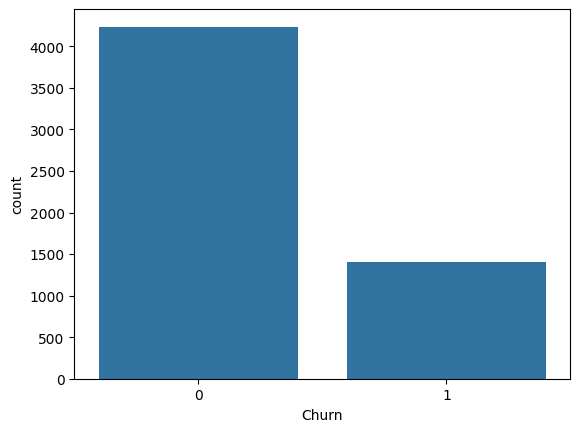

In [16]:
sns.countplot(x=rfm["Churn"])

In [18]:
joblib.dump(model, "../models/churn_model.pkl")

['../models/churn_model.pkl']